In [112]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost
from xgboost import XGBClassifier  
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
print(xgboost.__version__)

RANDOM_STATE=55

3.1.3


In [113]:
df=pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


one hot encoding using pandas:
first we will remove the binary variables because the one hot encoding won't do anything. to achive this, we will just count how many different values there are in each categorical variable and consider only the variable with 3 or more values.

In [114]:
cat_variables=['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']


 one-hot encoding aims to transform a categorical variable with n outputs into n binary variables.
 Pandas has a built-in method to one-hot encode variables, it is the function pd.get_dummies. There are several arguments to this function, but here we will use only a few. They are:

data: DataFrame to be used
prefix: A list with prefixes, so we know which value we are dealing with
columns: the list of columns that will be one-hot encoded. 'prefix' and 'columns' must have the same length.
For more information, you can always type help(pd.get_dummies) to read the function's full documentation.

In [115]:
df=pd.get_dummies(data=df,
                  prefix=cat_variables,
                  columns=cat_variables)

In [116]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


Let's choose the variables that will be the input features of the model.

The target is HeartDisease.
All other variables are features that can potentially be used to predict the target, HeartDisease.

In [117]:
features=[x for x in df.columns if x not in 'HeartDisease'] # removeing heartdisease from input features
print(len(features))
print(features)

20
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


In [118]:
# splitting the dataset
x_train,x_val,y_train,y_val=train_test_split(df[features],df['HeartDisease'],train_size=0.8,random_state=RANDOM_STATE)


In [119]:
print(f'train samples: {len(x_train)}')
print(f'validation samples: {len(x_val)}')
print(f'target proportion: {sum(y_train)/len(y_train):0.4f}')

train samples: 734
validation samples: 184
target proportion: 0.5518


here are several hyperparameters in the Decision Tree object from Scikit-learn. We will use only some of them and also we will not perform feature selection nor hyperparameter tuning in this lab

The hyperparameters we will use and investigate here are:

**min_samples_split**: The minimum number of samples required to split an internal node.
Choosing a higher min_samples_split can reduce the number of splits and may help to reduce overfitting.
**max_depth**: The maximum depth of the tree.
Choosing a lower max_depth can reduce the number of splits and may help to reduce overfitting.


In [120]:
# building the model
min_samples_split_list=[2,10,30,50,100,200,300,700]
max_depth_list=[1,2,3,4,8,16,32,64,None]


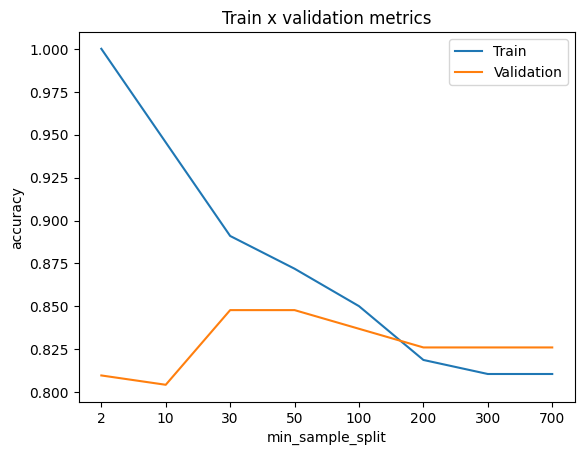

In [121]:
accuracy_list_train=[]
accuracy_list_val=[]
for min_sample_split in min_samples_split_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model=DecisionTreeClassifier(min_samples_split=min_sample_split,random_state=RANDOM_STATE).fit(x_train,y_train)
    prediction_train=model.predict(x_train)
    prediction_val=model.predict(x_val)
    accuracy_train=accuracy_score(prediction_train,y_train)
    accuracy_val=accuracy_score(prediction_val,y_val)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)
    
plt.title('Train x validation metrics')   
plt.xlabel('min_sample_split')
plt.ylabel('accuracy')
plt.xticks(ticks=range(len(min_samples_split_list)),labels=min_samples_split_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train','Validation'])

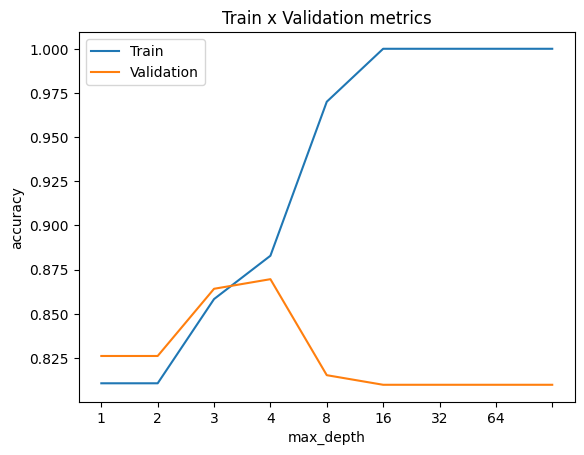

In [122]:
# lets do some experiment with max depth
accuracy_list_train=[]
accuracy_list_val=[]

for max_depth in max_depth_list:
    model=DecisionTreeClassifier(max_depth=max_depth,
                                 random_state=RANDOM_STATE).fit(x_train,y_train)
    prediction_train=model.predict(x_train)
    prediction_val=model.predict(x_val)
    accuracy_train=accuracy_score(y_train,prediction_train)
    accuracy_val=accuracy_score(y_val,prediction_val)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train x Validation metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train','Validation'])
    


**Note how increasing the the number of min_samples_split reduces overfitting.**

Increasing min_samples_split from 10 to 30, and from 30 to 50, even though it does not improve the validation accuracy, it brings the training accuracy closer to it, showing a reduction in overfitting.\


****we can see that in general, reducing max_depth can help to reduce overfitting.
****
Reducing max_depth from 8 to 4 increases validation accuracy closer to training accuracy, while significantly reducing training accuracy.
The validation accuracy reaches the highest at tree_depth=4.
When the max_depth is smaller than 3, both training and validation accuracy decreases. The tree cannot make enough splits to distinguish positives from negatives (the model is underfitting the training set).
When the max_depth is too high ( >= 5), validation accuracy decreases while training accuracy increases, indicating that the model is overfitting to the training set.
So we can choose the best values for these two hyper-parameters for our model to be:

max_depth = 4
min_samples_split = 50

In [123]:
decision_tree_model=DecisionTreeClassifier(min_samples_split=50, max_depth=4,random_state=RANDOM_STATE).fit(x_train,y_train)

In [124]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(decision_tree_model.predict(x_train),y_train):.4f}")
print(f"Metrics validation:\n\tAccuracy score: {accuracy_score(decision_tree_model.predict(x_val),y_val):.4f}")

Metrics train:
	Accuracy score: 0.8665
Metrics validation:
	Accuracy score: 0.8696


** Random Forest**
Now let's try the Random Forest algorithm also, using the Scikit-learn implementation.

All of the hyperparameters found in the decision tree model will also exist in this algorithm, since a random forest is an ensemble of many Decision Trees.
One additional hyperparameter for Random Forest is called n_estimators which is the number of Decision Trees that make up the Random Forest.
Remember that for a Random Forest, we randomly choose a subset of the features AND randomly choose a subset of the training examples to train each individual tree.

Following the lectures, if  𝑛
  is the number of features, we will randomly select  𝑛⎯⎯√
  of these features to train each individual tree.
Note that you can modify this by setting the max_features parameter.
You can also speed up your training jobs with another parameter, n_jobs.

Since the fitting of each tree is independent of each other, it is possible fit more than one tree in parallel.
So setting n_jobs higher will increase how many CPU cores it will use. Note that the numbers very close to the maximum cores of your CPU may impact on the overall performance of your PC and even lead to freezes.
Changing this parameter does not impact on the final result but can reduce the training time.
We will run the same script again, but with another parameter, n_estimators, where we will choose between 10, 50, and 100. The default is 100.

In [125]:
min_samples_split_list=[2,10,30,50,100,300,700]## If the number is an integer, then it is the actual quantity of samples,
                                             ## If it is a float, then it is the percentage of the dataset
max_depth_list = [2, 4, 8, 16, 32, 64, None]
n_estimators_list=[10,50,100,500]

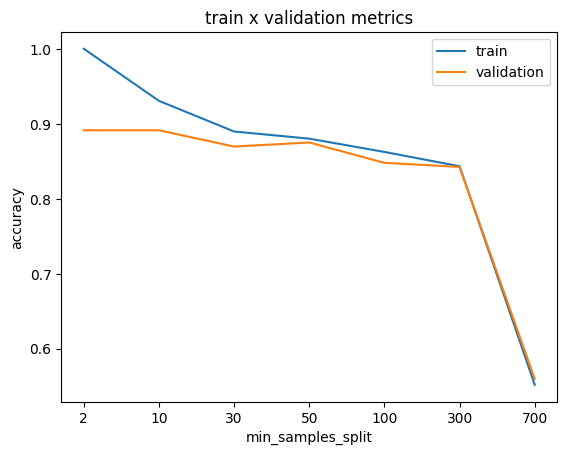

In [126]:
accuracy_list_train=[]
accuracy_list_val=[]
for min_sample_split in min_samples_split_list:
    model=RandomForestClassifier(min_samples_split=min_sample_split,random_state=RANDOM_STATE).fit(x_train,y_train)
    prediction_train=model.predict(x_train)
    prediction_val=model.predict(x_val)
    accuracy_train=accuracy_score(y_train,prediction_train)
    accuracy_val=accuracy_score(y_val,prediction_val)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)
    
plt.title('train x validation metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks=range(len(min_samples_split_list)),labels=min_samples_split_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['train','validation'])


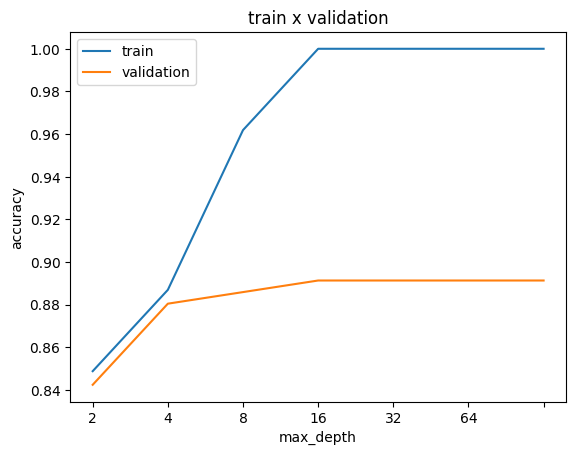

In [127]:
# now lets work with max-depth

accuracy_list_train=[]
accuracy_list_val=[]
for max_depth in max_depth_list:
    model=RandomForestClassifier(max_depth=max_depth,random_state=RANDOM_STATE).fit(x_train,y_train)
    prediction_train=model.predict(x_train)
    prediction_val=model.predict(x_val)
    accuracy_train=accuracy_score(y_train,prediction_train)
    accuracy_val=accuracy_score(y_val,prediction_val)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('train x validation')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks=range(len(max_depth_list)),labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['train','validation'])
    

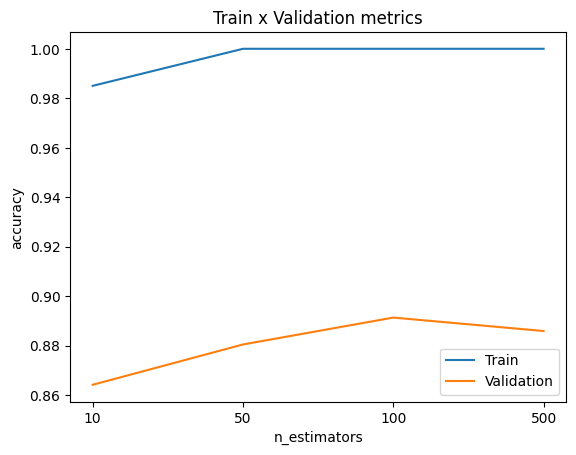

In [128]:
accuracy_list_train = []
accuracy_list_val = []
for n_estimators in n_estimators_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(n_estimators = n_estimators,
                                   random_state = RANDOM_STATE).fit(x_train,y_train) 
    predictions_train = model.predict(x_train) ## The predicted values for the train dataset
    predictions_val = model.predict(x_val) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_val = accuracy_score(predictions_val,y_val)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train x Validation metrics')
plt.xlabel('n_estimators')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(n_estimators_list )),labels=n_estimators_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train','Validation'])

Let's then fit a random forest with the following parameters:

max_depth: 16
min_samples_split: 10
n_estimators: 100

In [129]:
random_forest_model=RandomForestClassifier(n_estimators=100,max_depth=16,min_samples_split=10).fit(x_train,y_train)

In [130]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(random_forest_model.predict(x_train),y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(random_forest_model.predict(x_val),y_val):.4f}")

Metrics train:
	Accuracy score: 0.9292
Metrics test:
	Accuracy score: 0.8967


Note that we are searching for the best value one hyperparameter while leaving the other hyperparameters at their default values.

Ideally, we would want to check every combination of values for every hyperparameter that we are tuning.
If we have 3 hyperparameters, and each hyperparameter has 4 values to try out, we should have a total of 4 x 4 x 4 = 64 combinations to try.
When we only modify one hyperparameter while leaving the rest as their default value, we are trying 4 + 4 + 4 = 12 results.
To try out all combinations, we can use a sklearn implementation called GridSearchCV. GridSearchCV has a refit parameter that will automatically refit a model on the best combination so we will not need to program it explicitly. For more on GridSearchCV, please refer to its documentation.

**GridSearchCV is a hyperparameter tuning technique in scikit-learn.

👉 It automatically finds the best combination of hyperparameters for a model by:

Trying all possible combinations from a given parameter grid

Evaluating each combination using cross-validation

Selecting the combination that gives the best validation score
**

In [131]:

#    min_samples_split_list=[2,10,30,50,100,300,700]## If the number is an integer, then it is the actual quantity of samples,
#                                              ## If it is a float, then it is the percentage of the dataset
#    max_depth_list = [2, 4, 8, 16, 32, 64, None]
#    n_estimators_list=[10,50,100,500]

param_grid={
    'max_depth':[2,4,8,16,32,64,None],
    'n_estimators':[10,50,100,500],
    'min_samples_split':[2,10,30,50,100,300,700]
}

grid=GridSearchCV(
    estimator=random_forest_model,
    param_grid=param_grid,
    cv=5, # means training set is divided into 5(here) folds means: 5 times training and 5 time cross-validation
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(x_train,y_train)

# get best model:
print('best parameters:',grid.best_params_)
print('best cv score:',grid.best_score_)


best parameters: {'max_depth': 4, 'min_samples_split': 2, 'n_estimators': 50}
best cv score: 0.870496691827416


 **XGBoost**
Next is the Gradient Boosting model, called XGBoost. The boosting methods train several trees, but instead of them being uncorrelated to each other, now the trees are fit one after the other in order to minimize the error.

The model has the same parameters as a decision tree, plus the learning rate.

The learning rate is the size of the step on the Gradient Descent method that the XGBoost uses internally to minimize the error on each train step.
One interesting thing about the XGBoost is that during fitting, it can take in an evaluation dataset of the form (X_val,y_val).

On each iteration, it measures the cost (or evaluation metric) on the evaluation datasets.
Once the cost (or metric) stops decreasing for a number of rounds (called early_stopping_rounds), the training will stop.
More iterations lead to more estimators, and more estimators can result in overfitting.
By stopping once the validation metric no longer improves, we can limit the number of estimators created, and reduce overfitting.

In [132]:
n=int(len(x_train)*0.8) # lets use 80% to train and 20 to evaluate

x_train_fit,x_train_eval,y_train_fit,y_train_eval=x_train[:n],x_train[n:],y_train[:n],y_train[n:]

eval_set = [(X_train_eval,y_train_eval)]:Here we must pass a list to the eval_set, because you can have several different tuples ov eval sets.
early_stopping_rounds: This parameter helps to stop the model training if its evaluation metric is no longer improving on the validation set. It's set to 10.
The model keeps track of the round with the best performance (lowest evaluation metric). For example, let's say round 16 has the lowest evaluation metric so far.
Each successive round's evaluation metric is compared to the best metric. If the model goes 10 rounds where none have a better metric than the best one, then the model stops training.
The model is returned at its last state when training terminated, not its state during the best round. For example, if the model stops at round 26, but the best round was 16, the model's training state at round 26 is returned, not round 16.
Note that this is different from returning the model's "best" state (from when the evaluation metric was the lowest).

early_stopping_rounds: 10
we are traing the model and lets say the best state is 16 at which the error is mininmum till now, what does early_stopping_rounds do is that after best state to next 10 steps i.e. 26 here (16+10) if error don't decrease from the best state error so far then it will stop training 

In [136]:
xgb_model = XGBClassifier(n_estimators = 500, learning_rate = 0.1,verbosity = 1, random_state = RANDOM_STATE,early_stopping_rounds=10)
xgb_model.fit(x_train_fit,y_train_fit,eval_set=[(x_train_eval,y_train_eval)])


[0]	validation_0-logloss:0.63301
[1]	validation_0-logloss:0.59553
[2]	validation_0-logloss:0.56612
[3]	validation_0-logloss:0.54186
[4]	validation_0-logloss:0.52348
[5]	validation_0-logloss:0.50610
[6]	validation_0-logloss:0.49371
[7]	validation_0-logloss:0.48365
[8]	validation_0-logloss:0.47321
[9]	validation_0-logloss:0.46537
[10]	validation_0-logloss:0.45999
[11]	validation_0-logloss:0.45620
[12]	validation_0-logloss:0.45482
[13]	validation_0-logloss:0.44974
[14]	validation_0-logloss:0.44494
[15]	validation_0-logloss:0.44072
[16]	validation_0-logloss:0.44078
[17]	validation_0-logloss:0.43935
[18]	validation_0-logloss:0.44206
[19]	validation_0-logloss:0.44536
[20]	validation_0-logloss:0.44321
[21]	validation_0-logloss:0.44310
[22]	validation_0-logloss:0.44419
[23]	validation_0-logloss:0.44797
[24]	validation_0-logloss:0.44843
[25]	validation_0-logloss:0.45337
[26]	validation_0-logloss:0.45206
[27]	validation_0-logloss:0.45435


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,10
,enable_categorical,False
,eval_metric,None


In [137]:
print('best iteration',xgb_model.best_iteration)
print('best score',xgb_model.best_score)

best iteration 17
best score 0.43935144799096243


In [138]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(xgb_model.predict(x_train),y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(xgb_model.predict(x_val),y_val):.4f}")

Metrics train:
	Accuracy score: 0.9319
Metrics test:
	Accuracy score: 0.8533
